# Executed results report

This compact report indexes the auditable tables and the complete 24-figure suite. Numerical statements come from saved test predictions, not hand-entered values.

In [1]:
from pathlib import Path
import json, sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from pmwm.common import load_config
config = load_config(ROOT / 'config.yaml')
print(f"Project root: {ROOT}")

Project root: /home/urad/S


In [2]:
import pandas as pd
summary = json.loads((ROOT / 'results/summary.json').read_text())
display(pd.DataFrame(summary.items(), columns=['result', 'value']))

,result,value
0,best_model,PMWM (full)
1,test_samples_seen,78804
2,test_samples_held_out,26268
3,ridge_alpha,0.1
4,pmwm_rmse_z,0.910381
5,backbone_rmse_z,0.918724
6,relative_rmse_improvement_over_backbone_percent,0.908181
7,pmwm_acc,0.586687
8,pmwm_crps_z,0.459176
9,coverage_90,0.897063


In [3]:
tables = sorted((ROOT / 'results/tables').glob('*.csv'))
pd.DataFrame({'table': [p.name for p in tables], 'rows': [len(pd.read_csv(p)) for p in tables]})

,table,rows
0,bootstrap_significance.csv,1
1,classification_probes.csv,4
2,continual_learning_matrix.csv,12
3,continual_learning_summary.csv,1
4,event_reliability.csv,10
5,extreme_event_metrics.csv,1
6,forecast_metrics.csv,128
7,imputation_metrics.csv,12
8,leaderboard.csv,8
9,memory_efficiency.csv,5


In [4]:
figures = pd.read_csv(ROOT / 'results/figure_manifest.csv')
display(figures[['figure','stem','caption']])

,figure,stem,caption
0,1,fig01_system_architecture,Streaming PMWM architecture and information flow.
1,2,fig02_data_coverage_and_anchors,Chronological data splits and globally distrib...
2,3,fig03_multivariate_era5_stream,Illustrative six-hourly ERA5 streams for contr...
3,4,fig04_seasonal_climatology,Training-period monthly temperature climatolog...
4,5,fig05_event_discovery_timeline,Detected high-anomaly event states in the eval...
5,6,fig06_training_convergence,"Training, validation, and auxiliary imputation..."
6,7,fig07_forecast_leaderboard,Aggregate out-of-time forecast performance acr...
7,8,fig08_skill_by_horizon,Forecast skill relative to climatology as lead...
8,9,fig09_target_horizon_improvement,PMWM RMSE improvement over the backbone for ev...
9,10,fig10_spatial_skill_map,Spatial distribution of PMWM improvements at s...


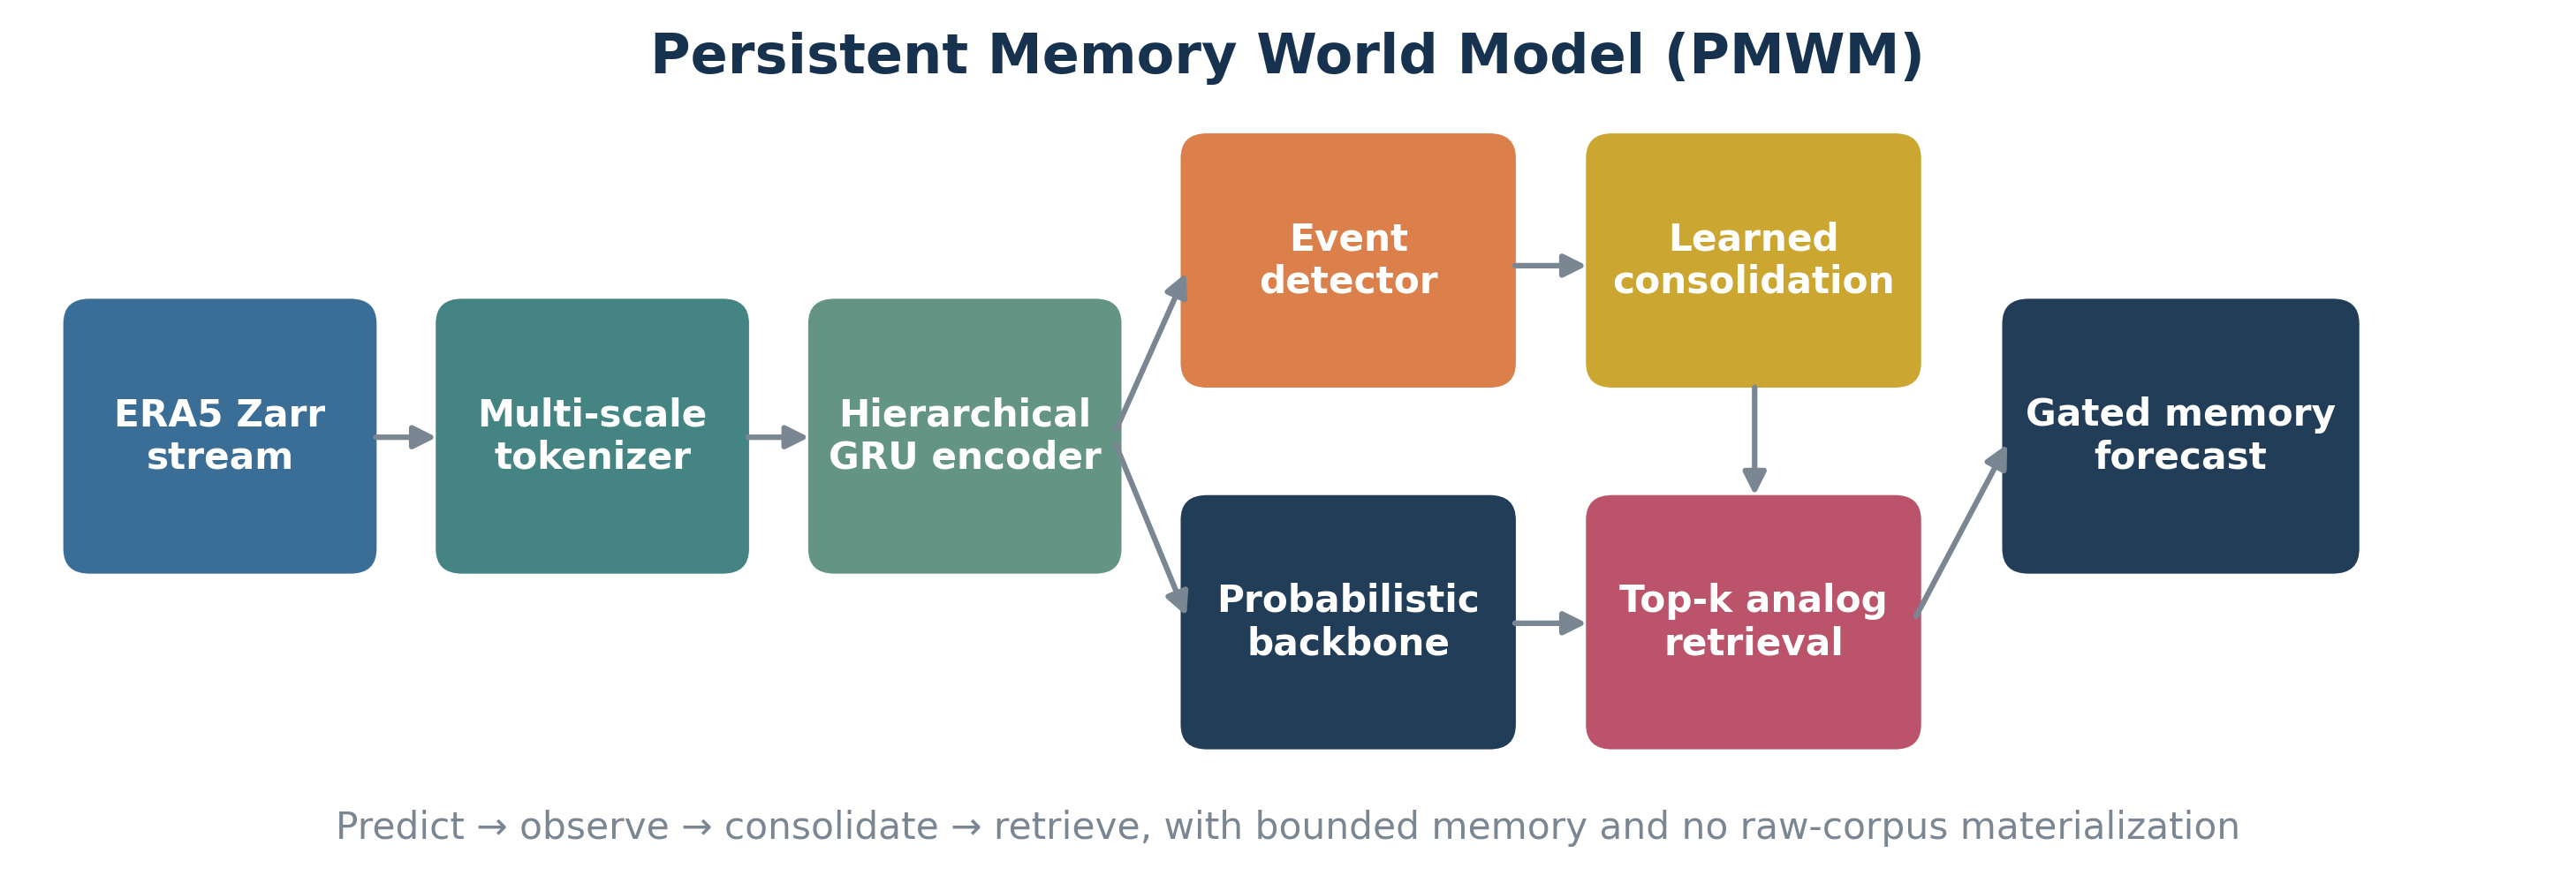

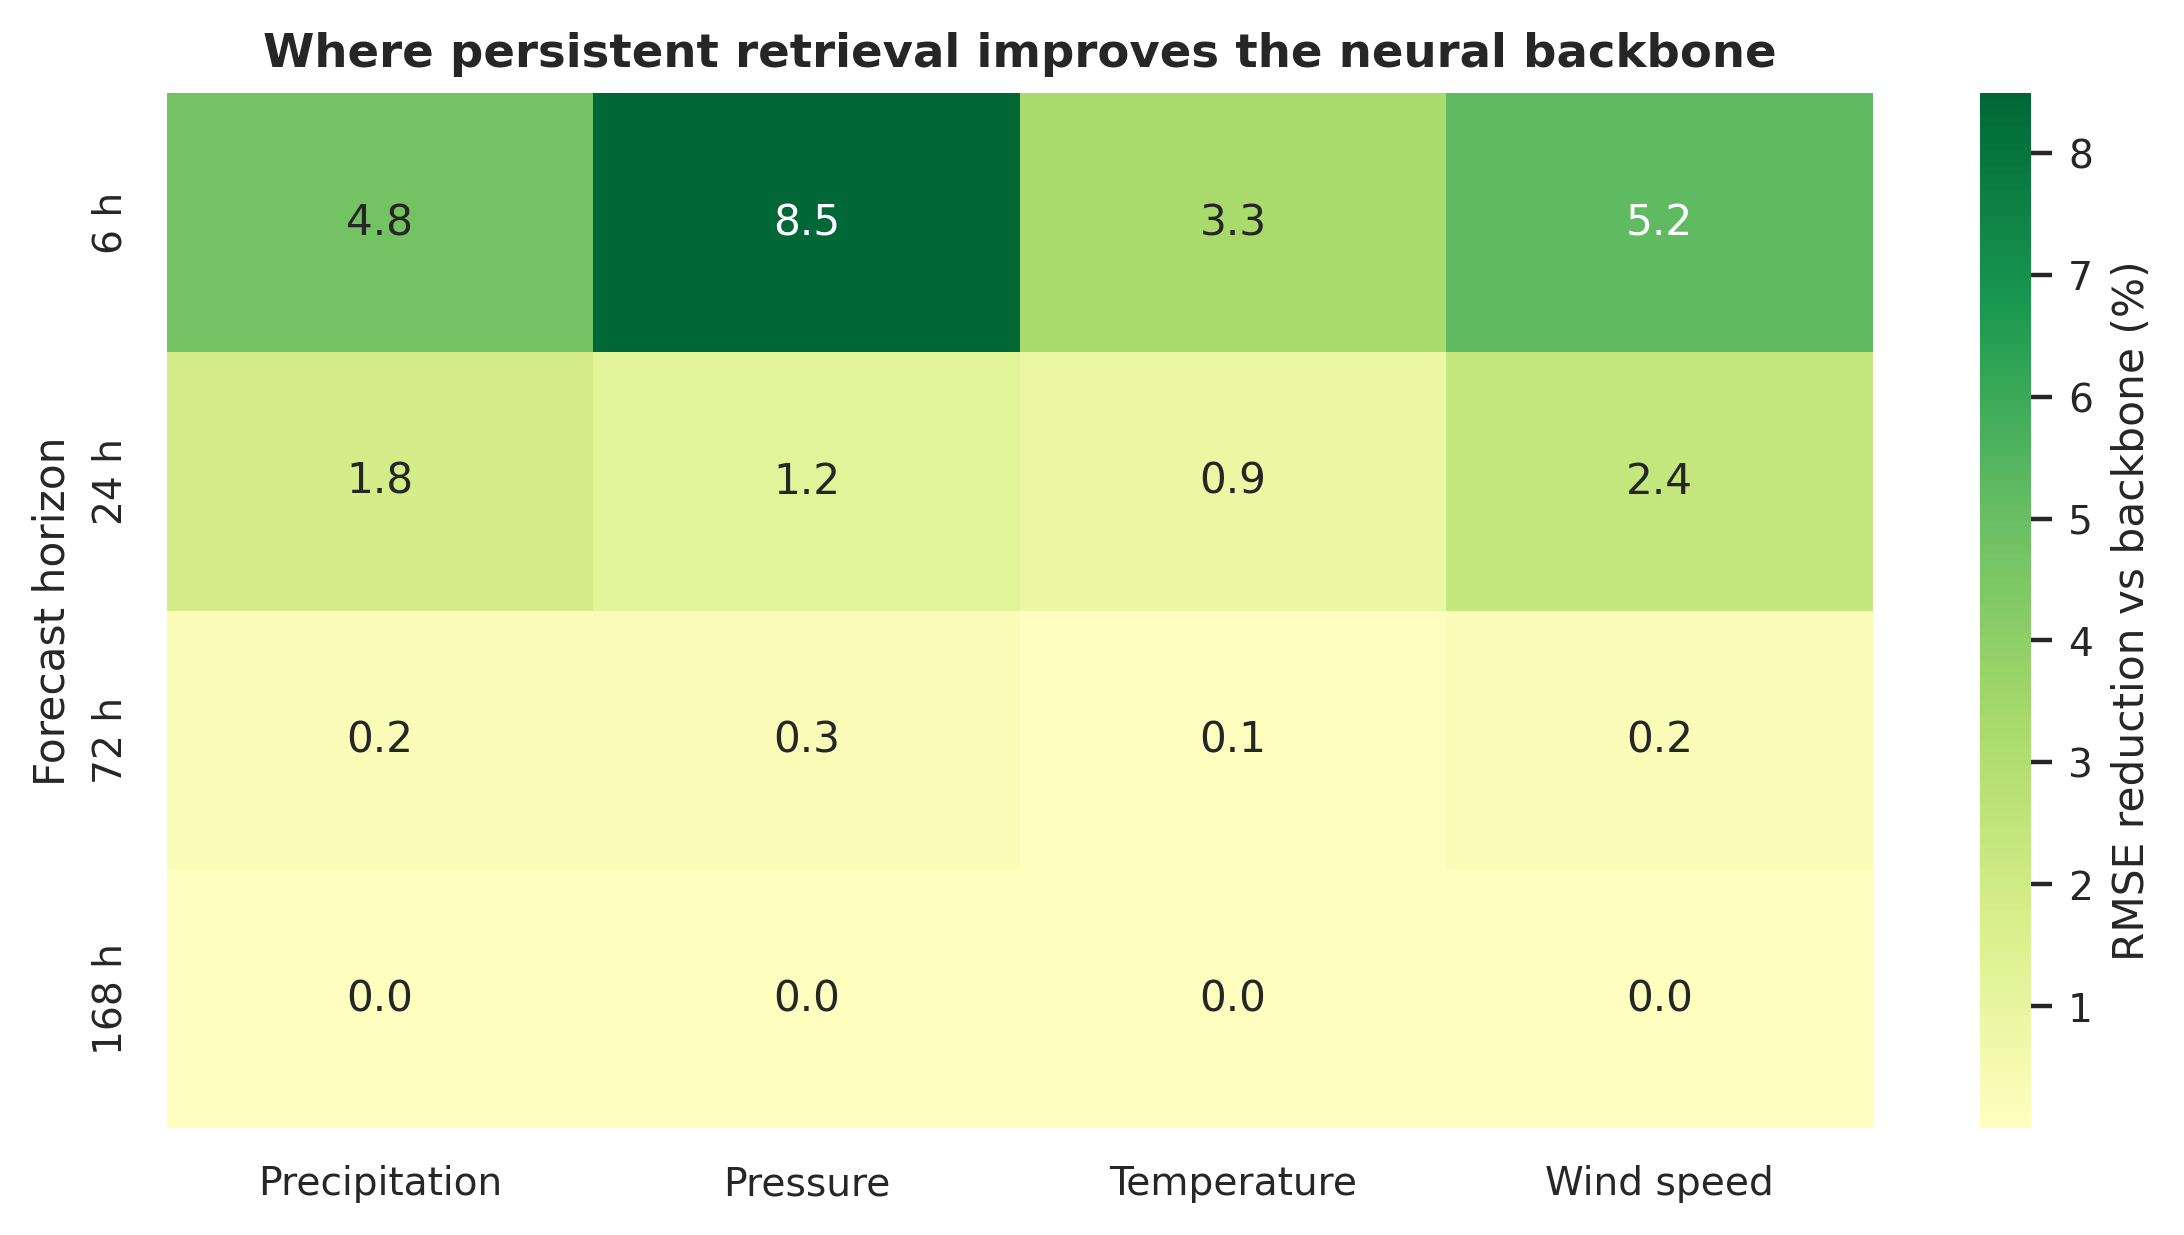

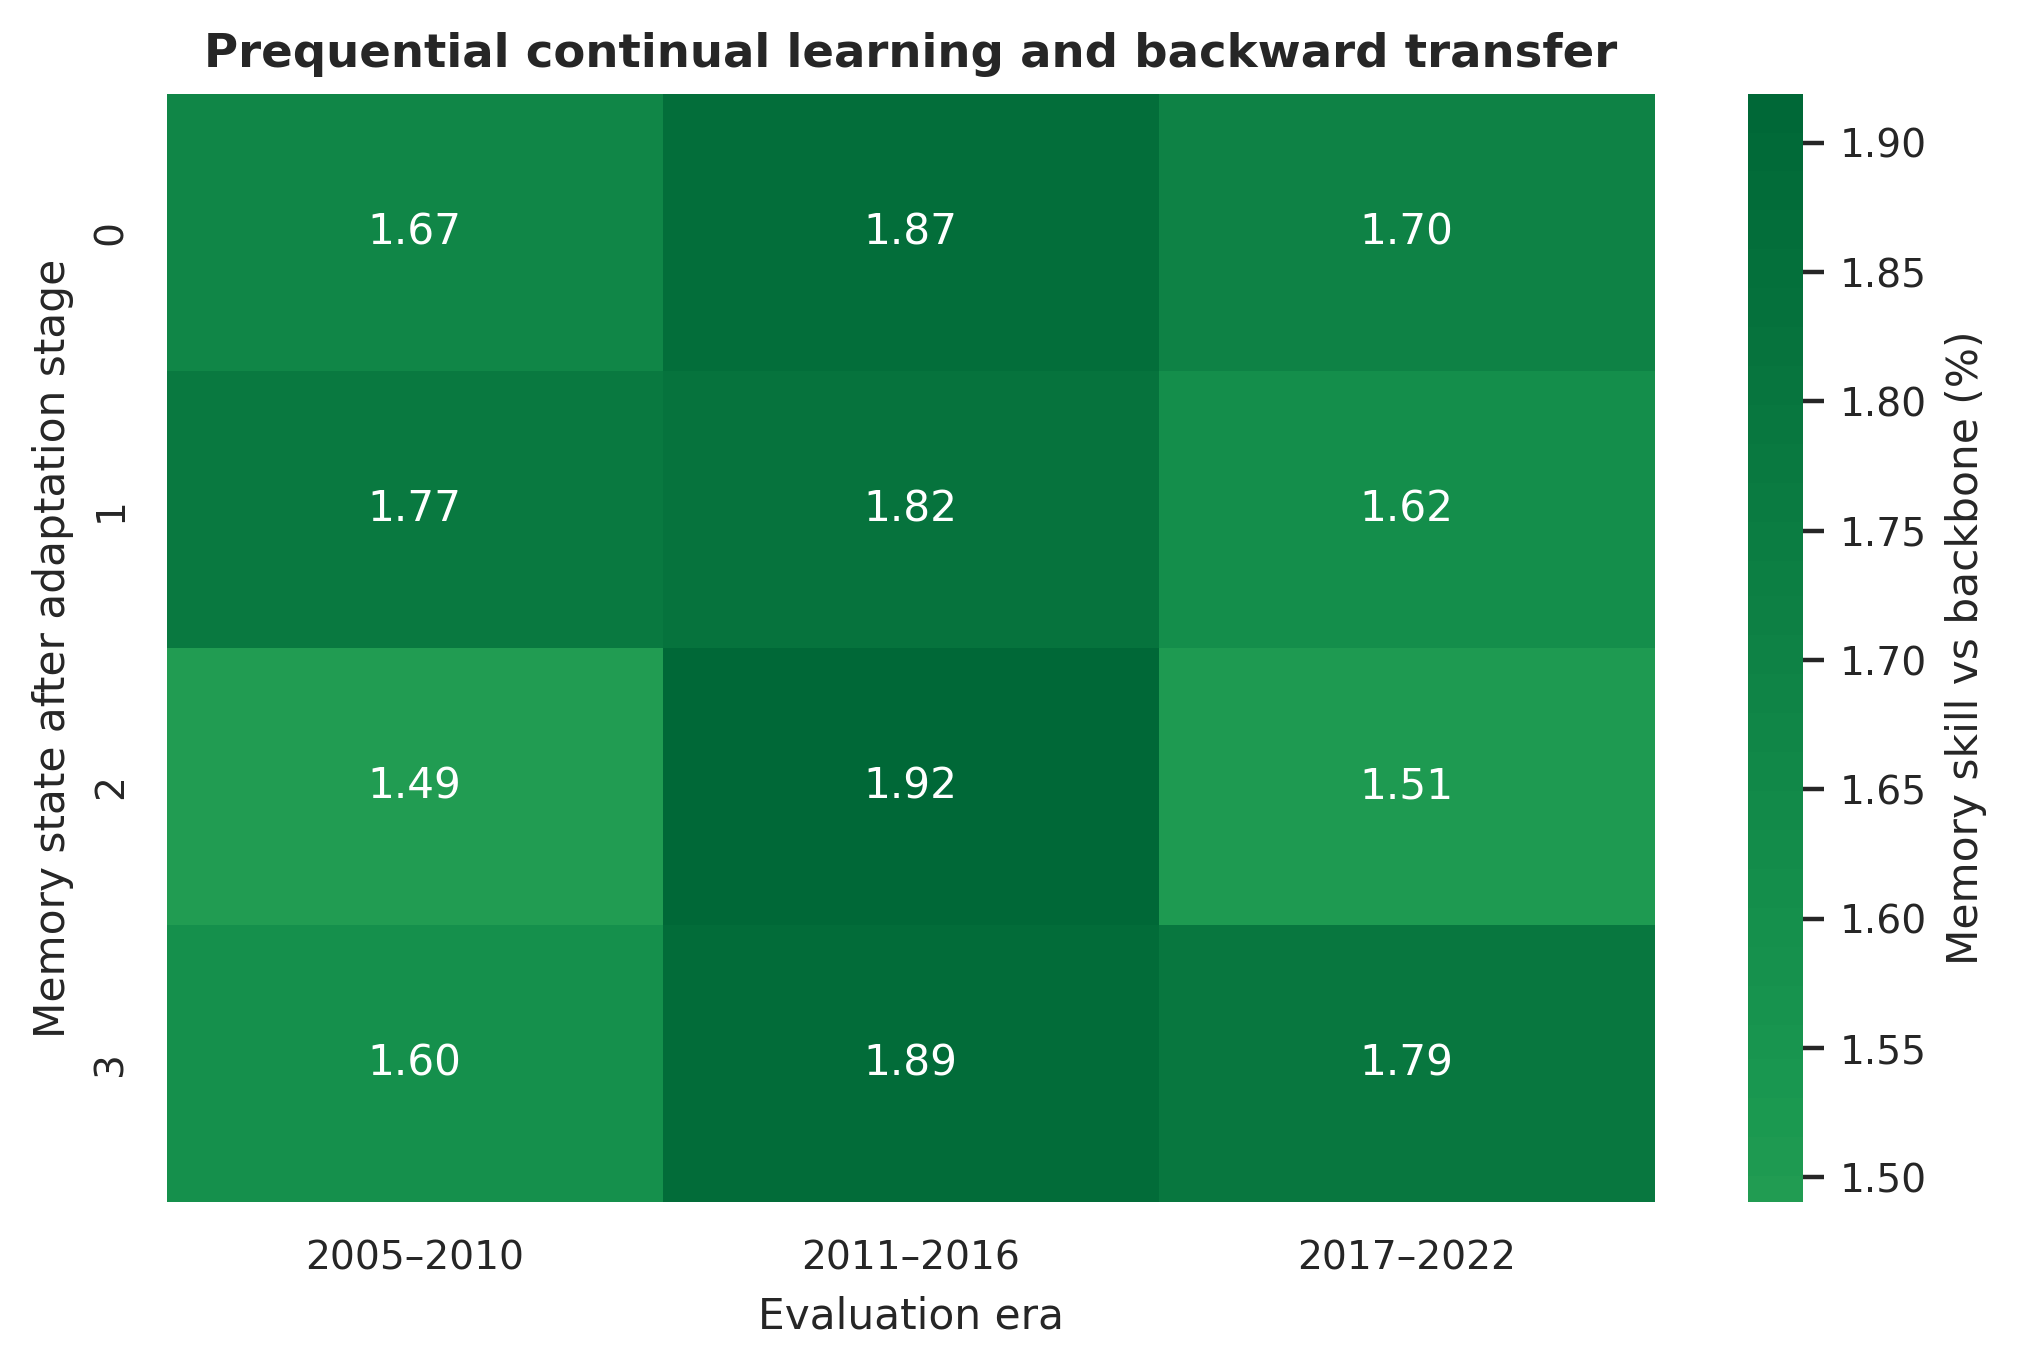

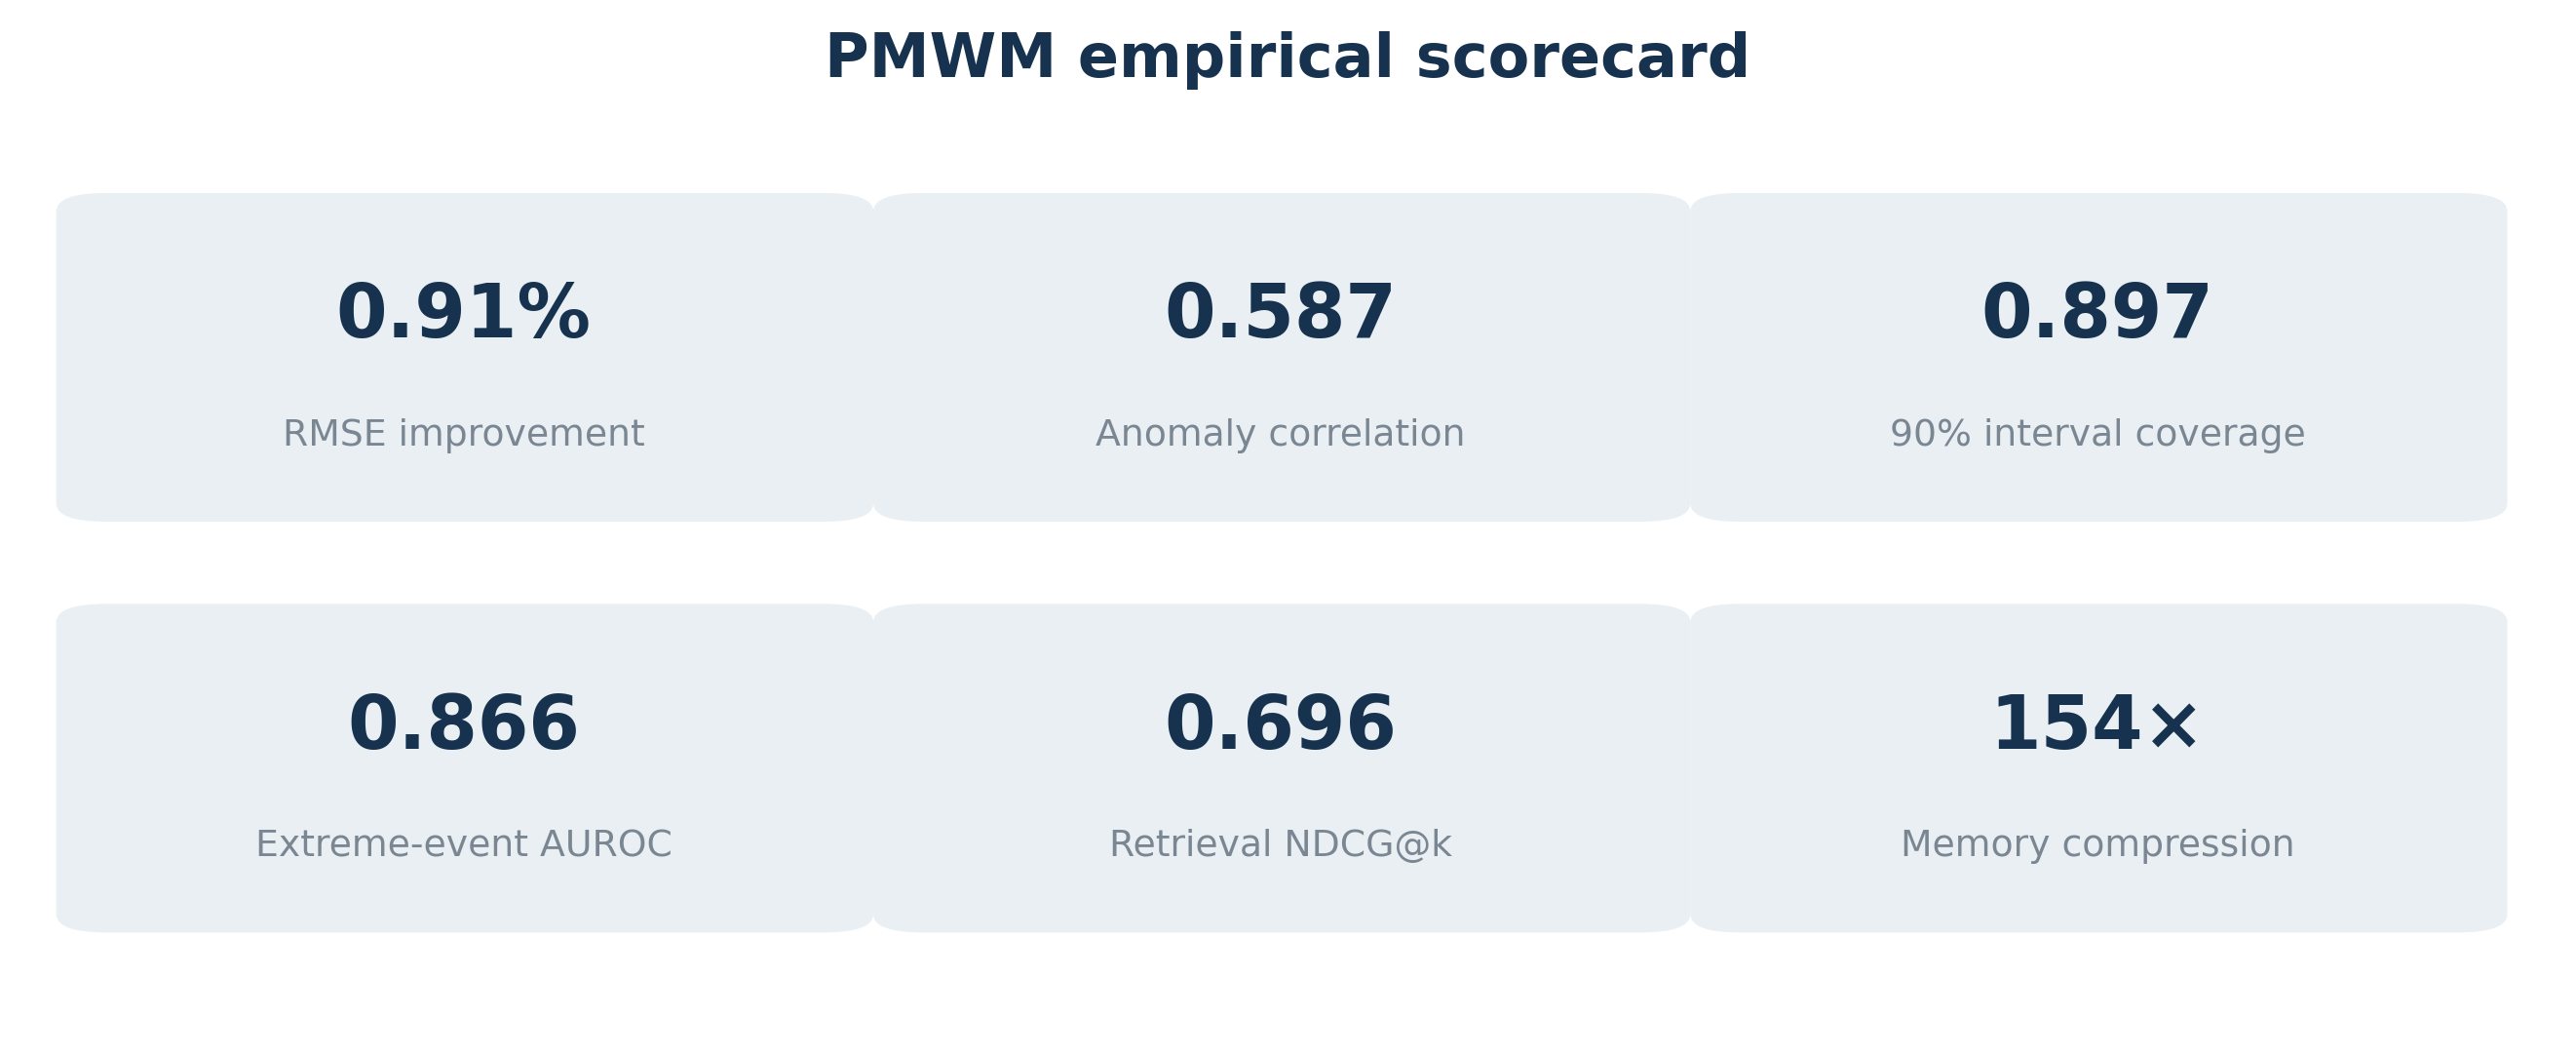

In [5]:
from IPython.display import Image, display
for name in ['fig01_system_architecture','fig09_target_horizon_improvement','fig19_continual_learning_matrix','fig24_empirical_scorecard']:
    display(Image(filename=ROOT / f'figures/png/{name}.png', width=900))